# 02. EDA и ABC/XYZ-сегментация

Ноутбук анализирует дневную витрину `sales_date × stock_code × market_id`, показывает распределения спроса и выручки, оценивает долю возвратов и строит ABC/XYZ-сегментацию.

In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR, RESULTS_DIR
from src.segmentation import build_abc_xyz_segments

In [6]:
mart_daily_sales = pd.read_csv(PROCESSED_DATA_DIR / 'mart_daily_sales.csv', parse_dates=['sales_date'])
mart_daily_sales.head()

,sales_date,stock_code,description,market_id,sales_qty,avg_unit_price,revenue,invoices_cnt,customers_cnt,returns_qty,net_sales_qty,weekday,month,year,is_weekend,is_return_flag,is_price_missing
0,2009-12-01,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,United Kingdom,46,9.430000,335.05,10,8,3,43,1,12,2009,False,True,False
1,2009-12-01,79323P,PINK CHERRY LIGHTS,United Kingdom,103,6.378571,588.15,7,7,2,101,1,12,2009,False,True,False
2,2009-12-01,79323W,WHITE CHERRY LIGHTS,United Kingdom,93,7.235000,565.72,12,10,1,92,1,12,2009,False,True,False
3,2009-12-01,22041,"RECORD FRAME 7"" SINGLE SIZE",United Kingdom,96,2.100000,201.60,2,2,0,96,1,12,2009,False,False,False
4,2009-12-01,21232,STRAWBERRY CERAMIC TRINKET BOX,United Kingdom,183,1.370000,244.59,11,10,0,183,1,12,2009,False,False,False


## Распределение чистого спроса

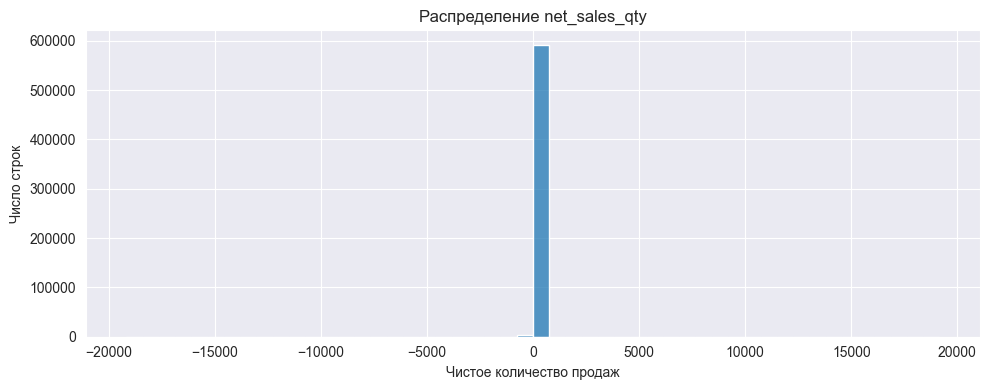

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(mart_daily_sales['net_sales_qty'], bins=50, ax=ax)
ax.set_title('Распределение net_sales_qty')
ax.set_xlabel('Чистое количество продаж')
ax.set_ylabel('Число строк')
plt.tight_layout()

## Распределение выручки

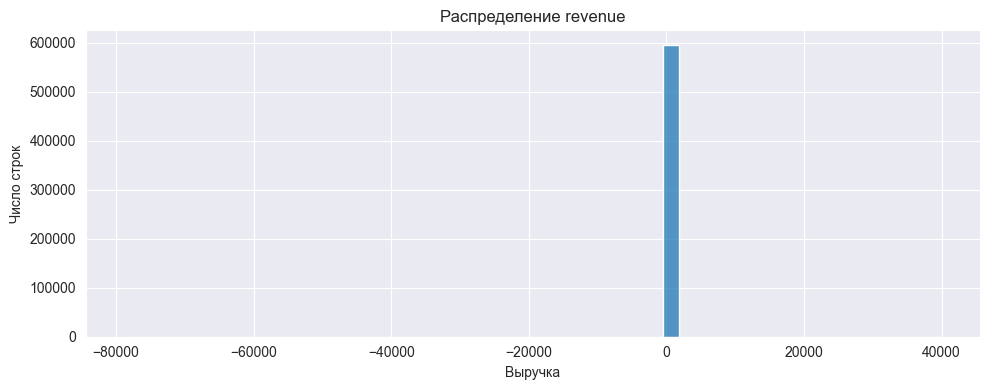

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(mart_daily_sales['revenue'], bins=50, ax=ax)
ax.set_title('Распределение revenue')
ax.set_xlabel('Выручка')
ax.set_ylabel('Число строк')
plt.tight_layout()

## Доля возвратов

In [9]:
returns_share = mart_daily_sales['is_return_flag'].mean()
returns_summary = pd.DataFrame({'metric': ['returns_share'], 'value': [returns_share]})
returns_summary

,metric,value
0,returns_share,0.034681


## Топ рынков по выручке

In [10]:
top_markets = (
    mart_daily_sales.groupby('market_id', as_index=False)
    .agg(revenue=('revenue', 'sum'), net_sales_qty=('net_sales_qty', 'sum'))
    .sort_values('revenue', ascending=False)
    .head(10)
)
top_markets

,market_id,revenue,net_sales_qty
40,United Kingdom,1.638258e+07,8692875
11,EIRE,6.155196e+05,331341
26,Netherlands,5.485249e+05,381951
15,Germany,4.179886e+05,224581
14,France,3.281918e+05,184952
0,Australia,1.671291e+05,103706
36,Switzerland,9.972876e+04,52378
34,Spain,9.185948e+04,45156
35,Sweden,8.780942e+04,87875
10,Denmark,6.574109e+04,235218


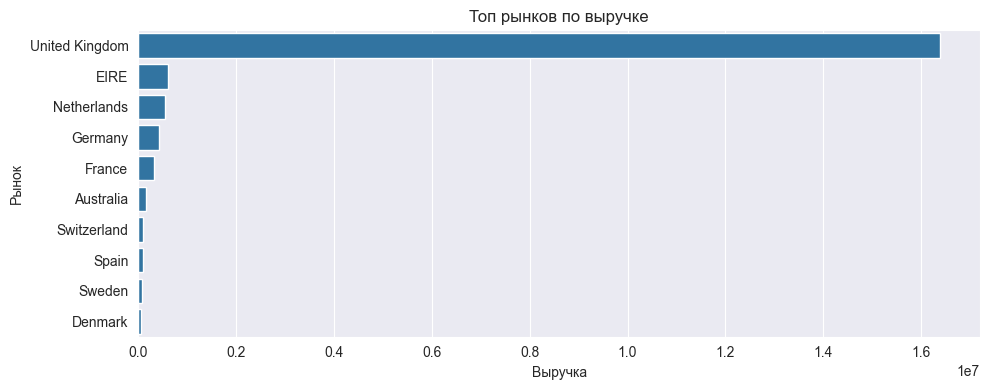

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=top_markets, x='revenue', y='market_id', ax=ax)
ax.set_title('Топ рынков по выручке')
ax.set_xlabel('Выручка')
ax.set_ylabel('Рынок')
plt.tight_layout()

## ABC/XYZ-сегментация

In [12]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
segments = build_abc_xyz_segments(mart_daily_sales, RESULTS_DIR / 'abc_xyz_segments.csv')
segments.head()

,stock_code,market_id,revenue,total_net_sales_qty,mean_net_sales_qty,std_net_sales_qty,active_days,value_share,cumulative_share,abc_segment,coefficient_of_variation,xyz_segment,abc_xyz_segment
0,79323W,United Kingdom,9977.02,-3350,-22.185430,395.868706,151,0.000517,0.519457,A,-17.843634,X,AX
1,C2,EIRE,9940.00,200,1.265823,0.590991,158,0.000515,0.519972,A,0.466883,X,AX
2,79323P,United Kingdom,8269.58,-901,-6.825758,179.018081,132,0.000429,0.560960,A,-26.226844,X,AX
3,ADJUST,United Kingdom,4920.41,-9,-4.500000,2.121320,2,0.000255,0.663239,A,-0.471405,X,AX
4,22433,United Kingdom,4405.56,-1848,-7.512195,268.883993,246,0.000228,0.683711,A,-35.792999,X,AX


In [13]:
segment_matrix = (
    segments.groupby(['abc_segment', 'xyz_segment'], as_index=False)
    .agg(items_cnt=('stock_code', 'count'), revenue=('revenue', 'sum'))
    .sort_values(['abc_segment', 'xyz_segment'])
)
segment_matrix

,abc_segment,xyz_segment,items_cnt,revenue
0,A,X,11,6.026316e+04
1,A,Y,166,9.042089e+05
2,A,Z,1432,1.446547e+07
3,B,X,240,1.789206e+05
4,B,Y,749,6.630150e+05
5,B,Z,1966,2.051268e+06
6,C,X,18789,4.359771e+05
7,C,Y,2594,2.255712e+05
8,C,Z,2857,3.025530e+05


## Выводы

- Доля строк с возвратами в дневной витрине: `[A]`.
- Рынки с максимальной выручкой: `[B]`.
- Сегменты AX/BX обычно удобнее для регулярного пополнения, потому что дают вклад в выручку и более стабильный спрос.
- Сегменты AZ/BZ/CZ требуют осторожного подхода: высокий разброс спроса может ухудшать прогноз и увеличивать риск ошибки в запасах.